# **1. Perkenalan Dataset**

Dataset Heart Disease ini berisi informasi medis pasien yang digunakan untuk memprediksi apakah seseorang memiliki penyakit jantung atau tidak (binary classification).

**Informasi Dataset:**
- **Jumlah data:** 1.025 baris
- **Jumlah fitur:** 13 fitur input + 1 target
- **Sumber:** [Kaggle - Heart Disease Dataset](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset)
- **Target:** `target` (0 = tidak sakit, 1 = sakit)

**Deskripsi Fitur:**
| Fitur | Deskripsi |
|-------|-----------|
| age | Usia pasien |
| sex | Jenis kelamin (1 = pria, 0 = wanita) |
| cp | Tipe nyeri dada (0-3) |
| trestbps | Tekanan darah saat istirahat (mm Hg) |
| chol | Kolesterol serum (mg/dl) |
| fbs | Gula darah puasa > 120 mg/dl (1 = ya, 0 = tidak) |
| restecg | Hasil elektrokardiografi saat istirahat (0-2) |
| thalach | Detak jantung maksimum |
| exang | Angina akibat olahraga (1 = ya, 0 = tidak) |
| oldpeak | Depresi ST akibat olahraga |
| slope | Kemiringan segmen ST puncak olahraga (0-2) |
| ca | Jumlah pembuluh darah utama (0-3) |
| thal | Tipe thalassemia (0-3) |
| target | Diagnosis penyakit jantung (0 = tidak, 1 = ya) |

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# Metrics
from sklearn.metrics import classification_report, confusion_matrix

# Kaggle API
import kaggle
import zipfile
import os

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Download dataset menggunakan Kaggle API
os.makedirs('heart_raw', exist_ok=True)

kaggle.api.authenticate()
kaggle.api.dataset_download_files(
    'johnsmith88/heart-disease-dataset',
    path='heart_raw',
    unzip=True
)

print("Dataset berhasil didownload!")
print("Isi folder heart_raw:", os.listdir('heart_raw'))

Dataset URL: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset
Dataset berhasil didownload!
Isi folder heart_raw: ['heart.csv']


In [3]:
# Load dataset
df = pd.read_csv('heart_raw/heart.csv')

# Cek beberapa baris awal
print("Shape dataset:", df.shape)
print("\n5 baris pertama:")
df.head()

Shape dataset: (1025, 14)

5 baris pertama:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [4]:
# Informasi dasar dataset
print("="*50)
print("INFORMASI DASAR DATASET")
print("="*50)
print(f"\nShape dataset: {df.shape}")
print(f"Jumlah fitur: {df.shape[1]-1}")
print(f"Jumlah sampel: {df.shape[0]}")
print("\nTipe data setiap kolom:")
print(df.dtypes)
print("\nStatistik deskriptif:")
df.describe()

INFORMASI DASAR DATASET

Shape dataset: (1025, 14)
Jumlah fitur: 13
Jumlah sampel: 1025

Tipe data setiap kolom:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Statistik deskriptif:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [5]:
# Cek missing values dan duplikat
print("="*50)
print("MISSING VALUES & DUPLIKAT")
print("="*50)
print("\nJumlah missing values per kolom:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"\nJumlah data duplikat: {df.duplicated().sum()}")

MISSING VALUES & DUPLIKAT

Jumlah missing values per kolom:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing values: 0

Jumlah data duplikat: 723


DISTRIBUSI TARGET
target
1    526
0    499
Name: count, dtype: int64

Persentase kelas:
target
1    51.317073
0    48.682927
Name: proportion, dtype: float64


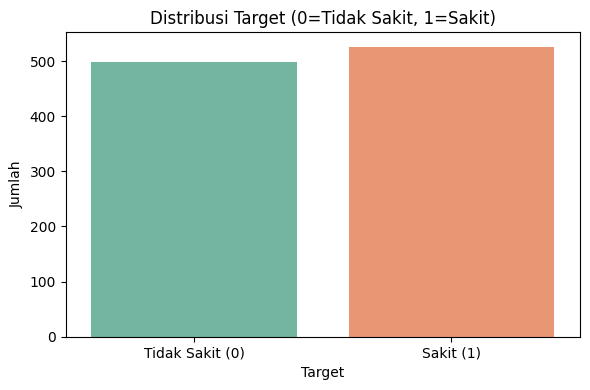

Plot berhasil disimpan!


In [6]:
# Distribusi target
print("="*50)
print("DISTRIBUSI TARGET")
print("="*50)
print(df['target'].value_counts())
print(f"\nPersentase kelas:")
print(df['target'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='Set2')
plt.title('Distribusi Target (0=Tidak Sakit, 1=Sakit)')
plt.xlabel('Target')
plt.ylabel('Jumlah')
plt.xticks([0, 1], ['Tidak Sakit (0)', 'Sakit (1)'])
plt.tight_layout()
plt.savefig('preprocessing/eda_target_distribution.png')
plt.show()
print("Plot berhasil disimpan!")

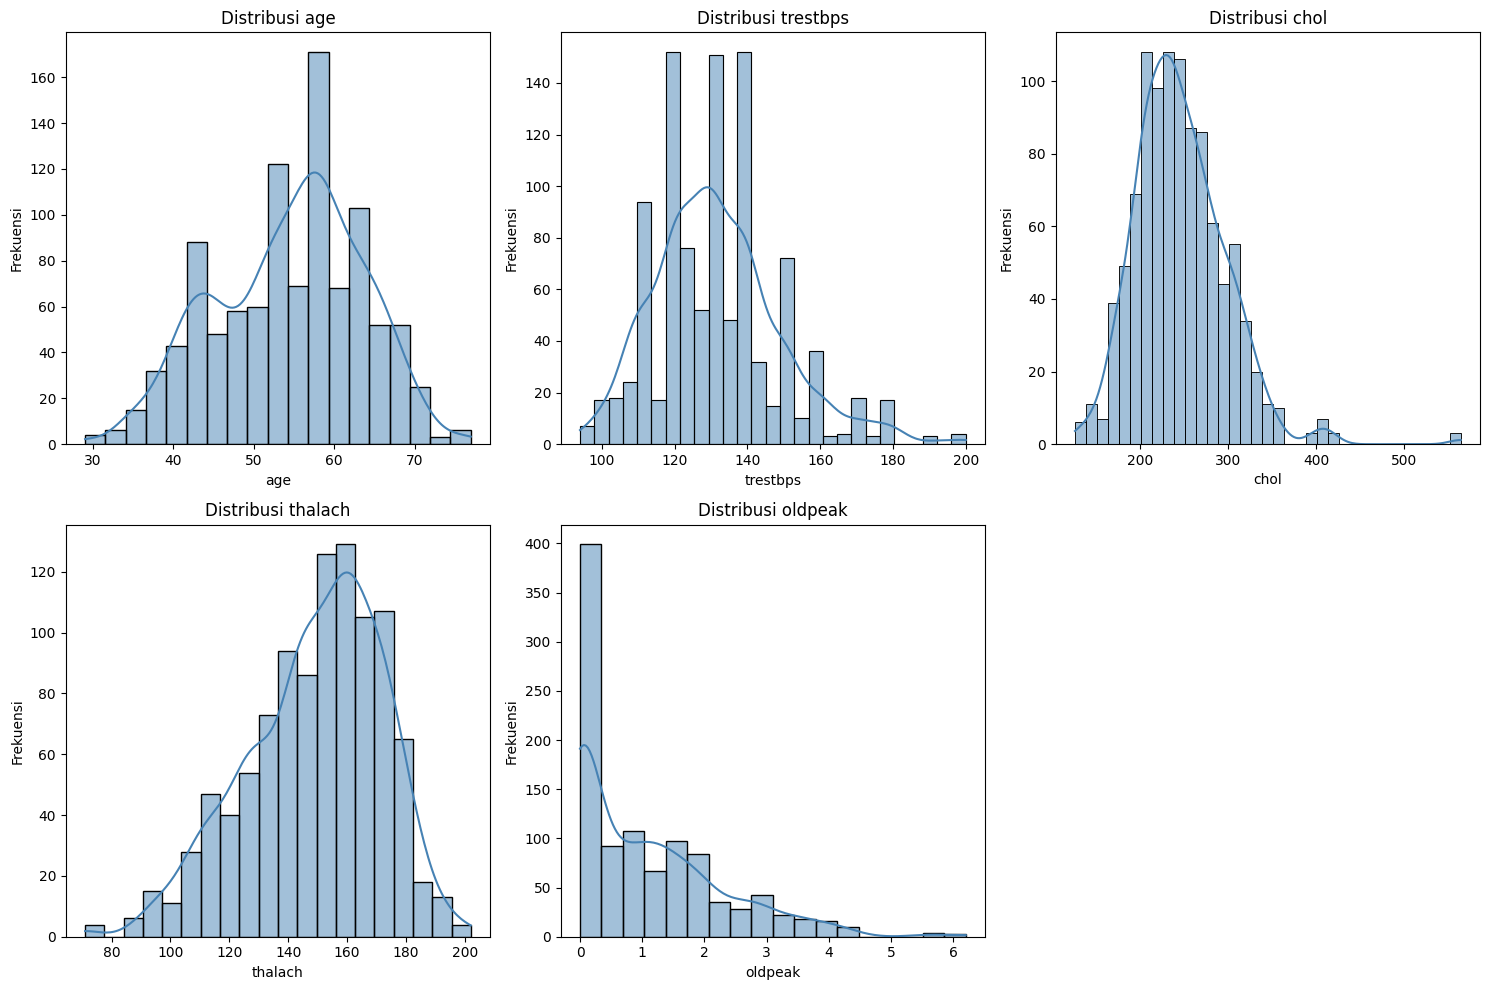

Plot berhasil disimpan!


In [7]:
# Distribusi fitur numerik
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, color='steelblue')
    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
plt.tight_layout()
plt.savefig('preprocessing/eda_numerical_distribution.png')
plt.show()
print("Plot berhasil disimpan!")

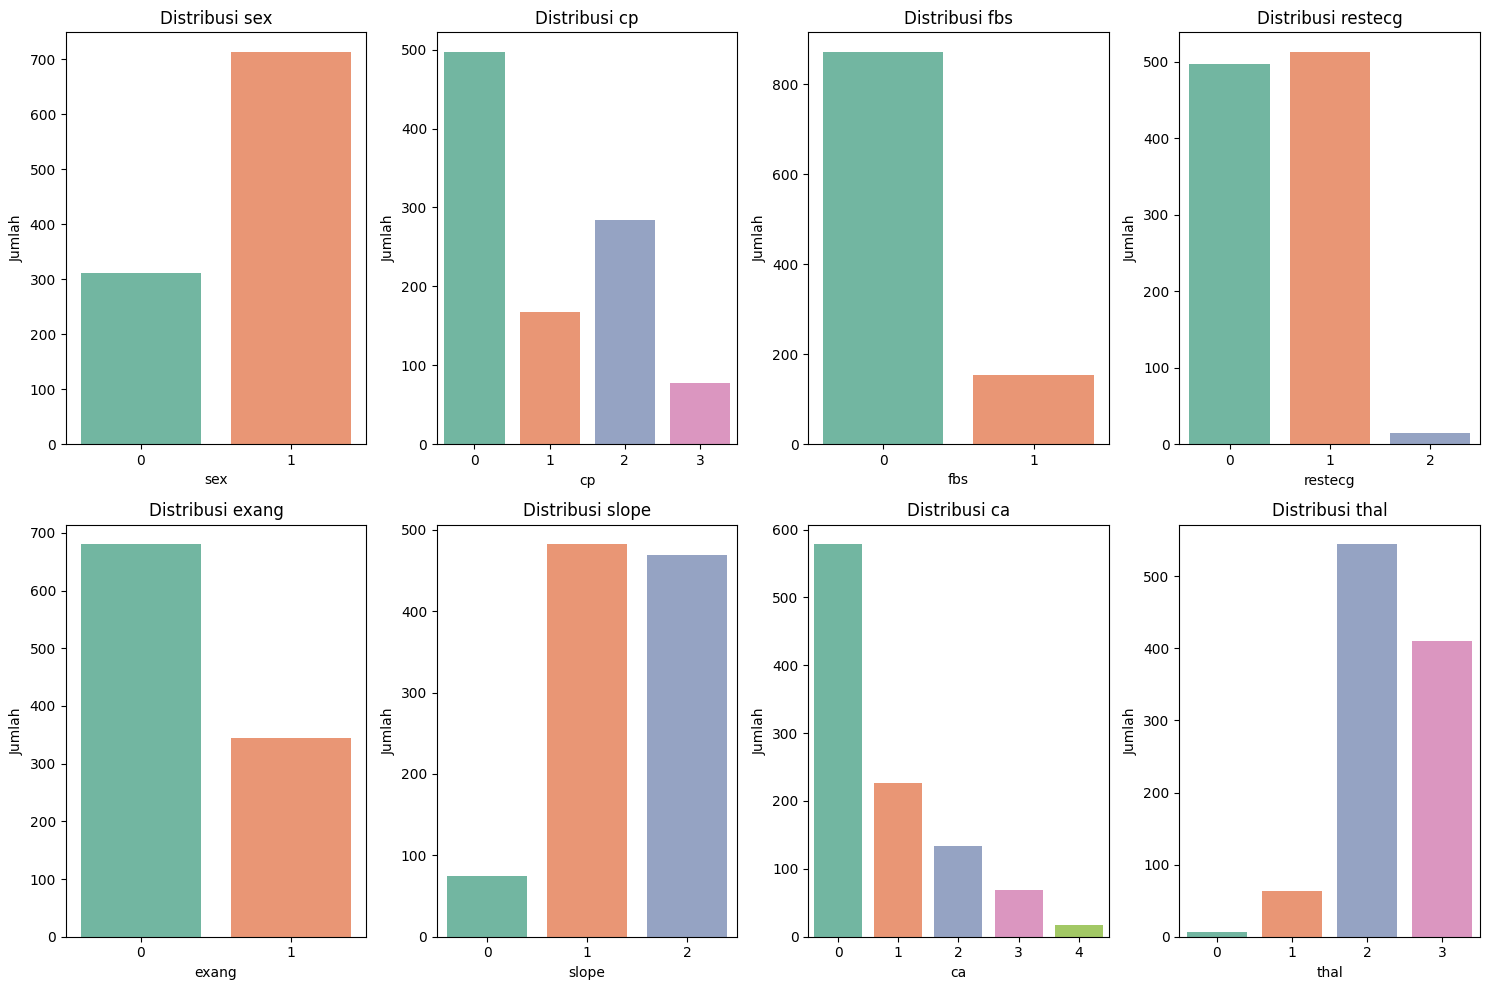

Plot berhasil disimpan!


In [8]:
# Distribusi fitur kategorikal
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 4, i)
    sns.countplot(x=col, data=df, palette='Set2')
    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Jumlah')
plt.tight_layout()
plt.savefig('preprocessing/eda_categorical_distribution.png')
plt.show()
print("Plot berhasil disimpan!")

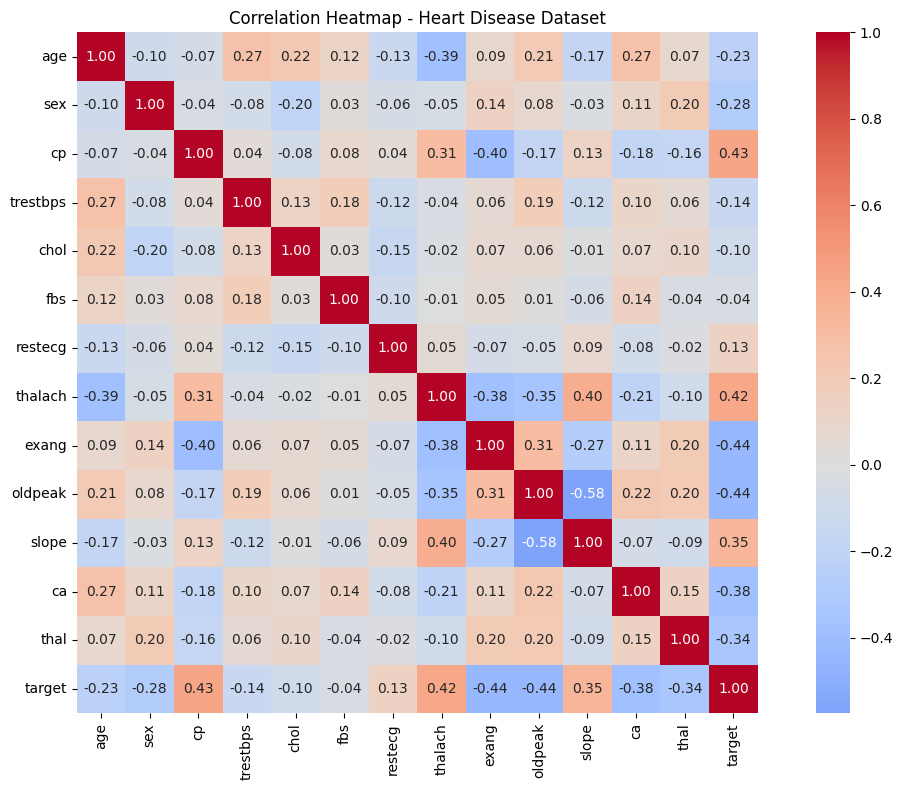

Plot berhasil disimpan!


In [9]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True
)
plt.title('Correlation Heatmap - Heart Disease Dataset')
plt.tight_layout()
plt.savefig('preprocessing/eda_correlation_heatmap.png')
plt.show()
print("Plot berhasil disimpan!")

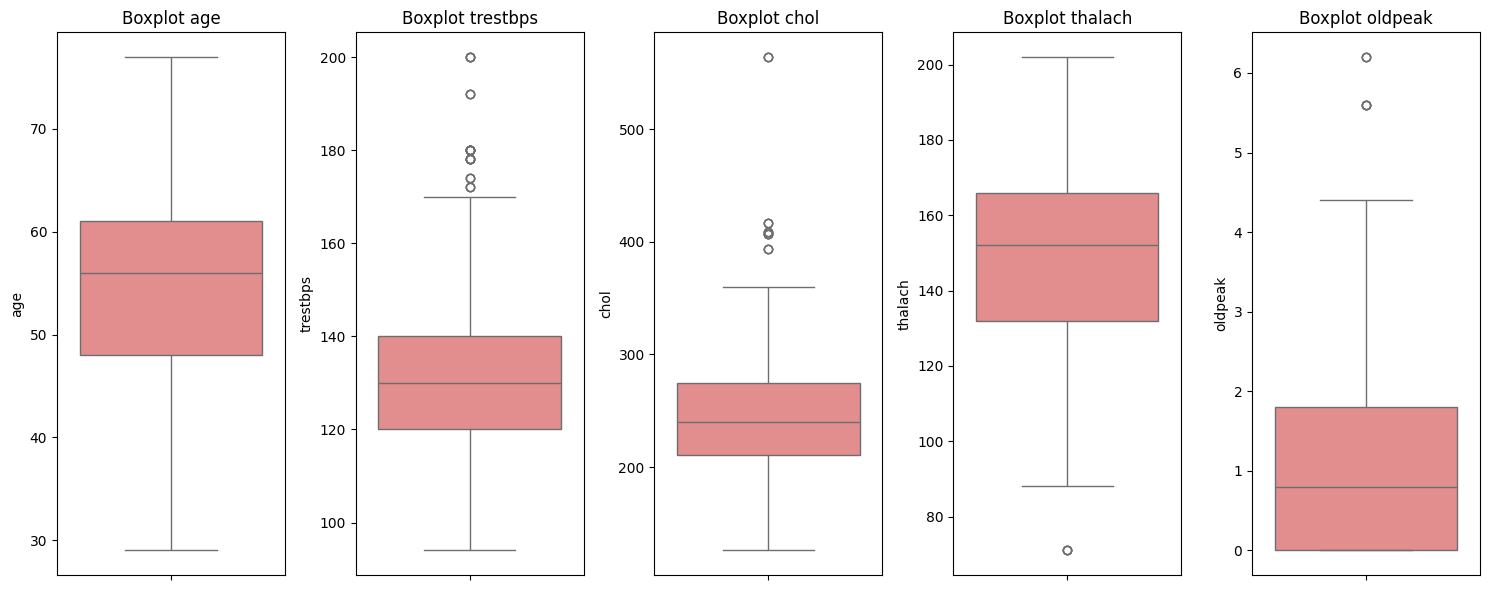

Plot berhasil disimpan!


In [10]:
# Boxplot untuk deteksi outlier pada fitur numerik
plt.figure(figsize=(15, 6))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, 5, i)
    sns.boxplot(y=df[col], color='lightcoral')
    plt.title(f'Boxplot {col}')
plt.tight_layout()
plt.savefig('preprocessing/eda_boxplot_outliers.png')
plt.show()
print("Plot berhasil disimpan!")

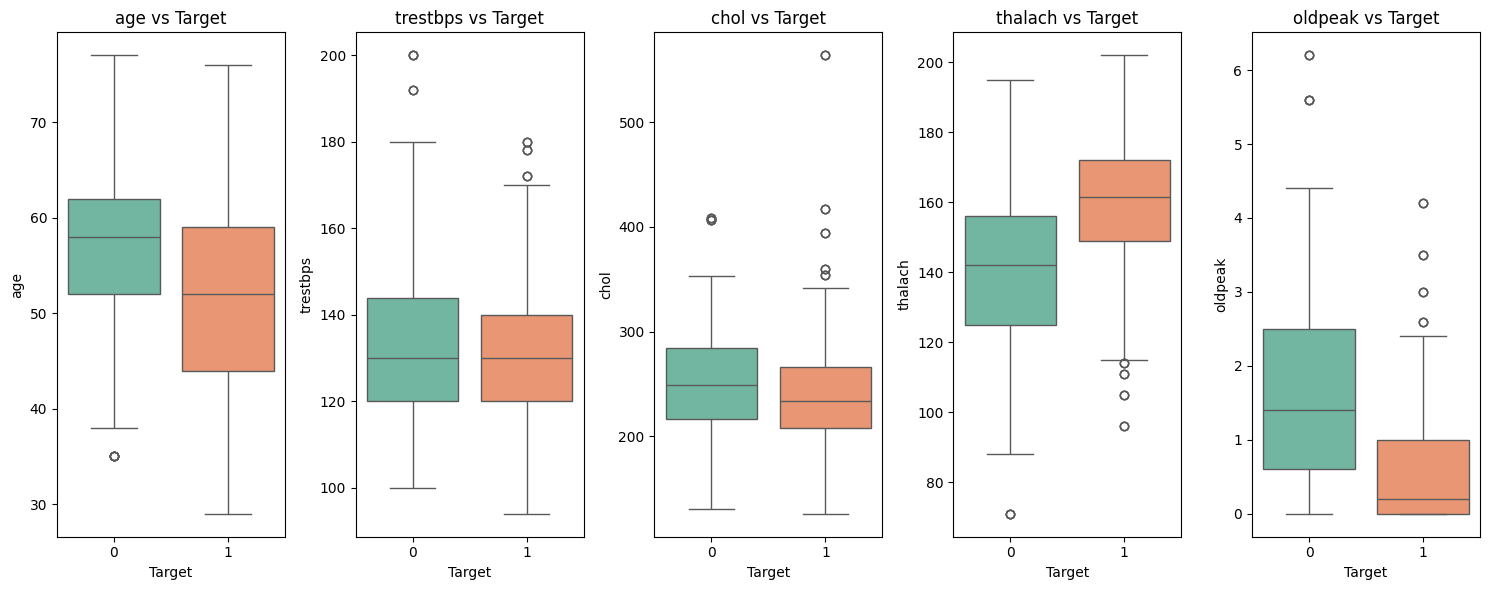

Plot berhasil disimpan!


In [11]:
# Hubungan fitur numerik dengan target
plt.figure(figsize=(15, 6))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, 5, i)
    sns.boxplot(x='target', y=col, data=df, palette='Set2')
    plt.title(f'{col} vs Target')
    plt.xlabel('Target')
plt.tight_layout()
plt.savefig('preprocessing/eda_features_vs_target.png')
plt.show()
print("Plot berhasil disimpan!")

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [12]:
print("="*50)
print("1. MENGHAPUS DATA DUPLIKAT")
print("="*50)

df_clean = df.copy()
print(f"Shape sebelum: {df_clean.shape}")
df_clean = df_clean.drop_duplicates()
print(f"Shape sesudah: {df_clean.shape}")
print(f"Jumlah duplikat yang dihapus: {df.shape[0] - df_clean.shape[0]}")

1. MENGHAPUS DATA DUPLIKAT
Shape sebelum: (1025, 14)
Shape sesudah: (302, 14)
Jumlah duplikat yang dihapus: 723


In [13]:
print("="*50)
print("2. MENANGANI OUTLIER (IQR METHOD)")
print("="*50)

numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

def remove_outliers_iqr(df, columns):
    df_out = df.copy()
    total_removed = 0
    for col in columns:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        before = df_out.shape[0]
        df_out = df_out[(df_out[col] >= lower) & (df_out[col] <= upper)]
        removed = before - df_out.shape[0]
        total_removed += removed
        print(f"  {col}: lower={lower:.2f}, upper={upper:.2f}, removed={removed} rows")
    return df_out

df_clean = remove_outliers_iqr(df_clean, numerical_cols)
print(f"\nShape setelah remove outlier: {df_clean.shape}")
print(f"Total baris dihapus: {df.shape[0] - df_clean.shape[0]}")

2. MENANGANI OUTLIER (IQR METHOD)
  age: lower=28.50, upper=80.50, removed=0 rows
  trestbps: lower=90.00, upper=170.00, removed=9 rows
  chol: lower=116.50, upper=368.50, removed=5 rows
  thalach: lower=79.12, upper=220.12, removed=1 rows
  oldpeak: lower=-2.40, upper=4.00, removed=4 rows

Shape setelah remove outlier: (283, 14)
Total baris dihapus: 742


In [14]:
print("="*50)
print("3. ENCODING FITUR KATEGORIKAL")
print("="*50)

categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# One-Hot Encoding untuk fitur kategorikal dengan lebih dari 2 nilai unik
# Label Encoding untuk fitur binary
binary_cols = ['sex', 'fbs', 'exang']
onehot_cols = ['cp', 'restecg', 'slope', 'ca', 'thal']

# Label encoding untuk binary
le = LabelEncoder()
for col in binary_cols:
    df_clean[col] = le.fit_transform(df_clean[col])
    print(f"Label Encoding: {col} -> {df_clean[col].unique()}")

# One-hot encoding
df_clean = pd.get_dummies(df_clean, columns=onehot_cols, drop_first=True)
print(f"\nShape setelah encoding: {df_clean.shape}")
print(f"Kolom setelah encoding:\n{list(df_clean.columns)}")

3. ENCODING FITUR KATEGORIKAL
Label Encoding: sex -> [1 0]
Label Encoding: fbs -> [0 1]
Label Encoding: exang -> [0 1]

Shape setelah encoding: (283, 23)
Kolom setelah encoding:
['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'target', 'cp_1', 'cp_2', 'cp_3', 'restecg_1', 'restecg_2', 'slope_1', 'slope_2', 'ca_1', 'ca_2', 'ca_3', 'ca_4', 'thal_1', 'thal_2', 'thal_3']


In [15]:
print("="*50)
print("4. NORMALISASI FITUR NUMERIK")
print("="*50)

# Pisahkan fitur dan target
X = df_clean.drop('target', axis=1)
y = df_clean['target']

# Normalisasi fitur numerik
scaler = StandardScaler()
numerical_cols_to_scale = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

X[numerical_cols_to_scale] = scaler.fit_transform(X[numerical_cols_to_scale])

print("Statistik setelah normalisasi:")
print(X[numerical_cols_to_scale].describe().round(3))

4. NORMALISASI FITUR NUMERIK
Statistik setelah normalisasi:
           age  trestbps     chol  thalach  oldpeak
count  283.000   283.000  283.000  283.000  283.000
mean    -0.000     0.000   -0.000   -0.000    0.000
std      1.002     1.002    1.002    1.002    1.002
min     -2.749    -2.336   -2.609   -2.735   -0.929
25%     -0.774    -0.643   -0.714   -0.727   -0.929
50%      0.104     0.008   -0.074    0.134   -0.343
75%      0.653     0.659    0.632    0.796    0.633
max      2.519     2.612    2.640    2.297    2.975


In [16]:
print("="*50)
print("5. SPLIT DATA (TRAIN & TEST)")
print("="*50)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Total data: {X.shape[0]}")
print(f"Train set: {X_train.shape[0]} ({X_train.shape[0]/X.shape[0]*100:.1f}%)")
print(f"Test set : {X_test.shape[0]} ({X_test.shape[0]/X.shape[0]*100:.1f}%)")
print(f"\nDistribusi target train:\n{y_train.value_counts()}")
print(f"\nDistribusi target test:\n{y_test.value_counts()}")

5. SPLIT DATA (TRAIN & TEST)
Total data: 283
Train set: 226 (79.9%)
Test set : 57 (20.1%)

Distribusi target train:
target
1    126
0    100
Name: count, dtype: int64

Distribusi target test:
target
1    32
0    25
Name: count, dtype: int64


In [17]:
print("="*50)
print("6. MENYIMPAN DATASET HASIL PREPROCESSING")
print("="*50)

# Gabungkan kembali X dan y
df_preprocessed = pd.concat([X_train, y_train], axis=1)
df_preprocessed_test = pd.concat([X_test, y_test], axis=1)

# Simpan ke folder preprocessing
os.makedirs('heart_preprocessed', exist_ok=True)

df_preprocessed.to_csv('heart_preprocessed/heart_train.csv', index=False)
df_preprocessed_test.to_csv('heart_preprocessed/heart_test.csv', index=False)

print(f"Train data disimpan: heart_preprocessed/heart_train.csv {df_preprocessed.shape}")
print(f"Test data disimpan : heart_preprocessed/heart_test.csv {df_preprocessed_test.shape}")
print("\nPreprocessing selesai!")

6. MENYIMPAN DATASET HASIL PREPROCESSING
Train data disimpan: heart_preprocessed/heart_train.csv (226, 23)
Test data disimpan : heart_preprocessed/heart_test.csv (57, 23)

Preprocessing selesai!
